In [14]:
import numpy as np
import random
import os
from skimage.io import imread 
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_addons as tfa
from main.BatchGeneratorTripletSemiHardLoss import BatchGenerator
import main.Metrics as metrics
from tensorflow.keras import layers, models
from keras.applications import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from scipy.spatial import distance
import pickle
import seaborn as sns
import pandas as pd
import cv2
import glob

In [2]:
path_images = "./dcface_0.5m_oversample_xid/dcface_0.5m_oversample_xid/images/"

NUM_IMGS = 5000
INPUT = (112, 112, 3)

In [3]:
data_files_train = [[path_images + str(id), id] for id in range(NUM_IMGS)]
batch_gen_train = BatchGenerator(data_files_train, batch_size = 128, dim = INPUT)

data_files_val = [[path_images + str(id), id] for id in range(NUM_IMGS, NUM_IMGS + 200)]
batch_gen_val = BatchGenerator(data_files_val, batch_size = 128, dim = INPUT)


In [12]:
#batch_gen_val.__getitem__(0)

## Model

In [3]:
backbone = DenseNet121(include_top = False,
                         weights = "imagenet",
                         input_shape = INPUT
                        )

for layer in backbone.layers:
    layer.trainable = False
                                            
inputs = layers.Input(shape=INPUT)

x = backbone(inputs)
x = tf.keras.layers.GlobalAveragePooling2D() (x)
dense1 = tf.keras.layers.Dense(units = 512, activation = 'relu')(x)
dense2 = tf.keras.layers.Dense(units = 256, activation = 'relu')(dense1)
outputs = tf.keras.layers.Dense(units = 256, activation = None)(dense2)

model = models.Model(inputs = inputs, outputs = outputs)

In [5]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(0.001),
    loss=tfa.losses.TripletSemiHardLoss(margin=0.5,
                                        distance_metric="angular"))

In [15]:
filepath="./models/model_semihard_v2.keras"
checkpoint = ModelCheckpoint(filepath, 
                             monitor = 'val_loss', 
                             verbose = 1,
                             save_best_only = True, 
                             mode = 'min')

In [16]:
# Train the network
history = model.fit(
    batch_gen_train,
    validation_data=batch_gen_val,
    epochs=1000,
    callbacks=checkpoint)

Epoch 1/1000


2024-07-12 18:14:18.008963: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


39/39 [==============================] - ETA: 0s - loss: 0.4928

2024-07-12 18:14:59.313008: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



Epoch 1: val_loss improved from inf to 0.48860, saving model to model_semihard.keras
39/39 [==============================] - 43s 1s/step - loss: 0.4928 - val_loss: 0.4886
Epoch 2/1000
39/39 [==============================] - ETA: 0s - loss: 0.4902
Epoch 2: val_loss did not improve from 0.48860
39/39 [==============================] - 35s 906ms/step - loss: 0.4902 - val_loss: 0.4928
Epoch 3/1000
39/39 [==============================] - ETA: 0s - loss: 0.4904
Epoch 3: val_loss improved from 0.48860 to 0.48667, saving model to model_semihard.keras
39/39 [==============================] - 34s 854ms/step - loss: 0.4904 - val_loss: 0.4867
Epoch 4/1000
39/39 [==============================] - ETA: 0s - loss: 0.4877
Epoch 4: val_loss improved from 0.48667 to 0.48598, saving model to model_semihard.keras
39/39 [==============================] - 36s 918ms/step - loss: 0.4877 - val_loss: 0.4860
Epoch 5/1000
39/39 [==============================] - ETA: 0s - loss: 0.4916
Epoch 5: val_loss did no

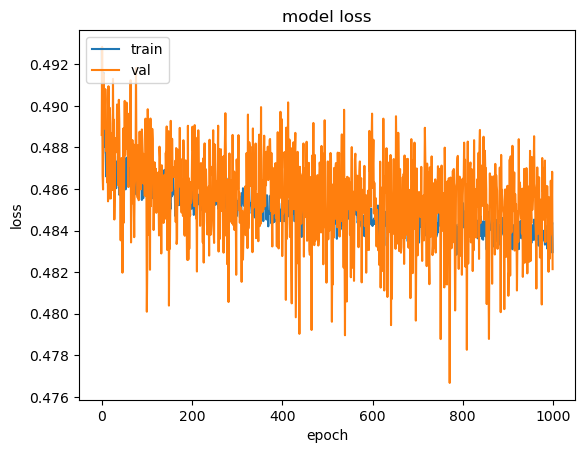

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Prediction

In [4]:
filepath = "./models/model_semihard_v2.keras"
model.load_weights(filepath)

In [67]:
with open('test_data.pkl', 'rb') as f:
    (true_pairs, true_pairs_1_test, true_pairs_2_test, false_pairs, false_pairs_1_test, false_pairs_2_test) = pickle.load(f)

In [68]:
# Postive-pairs prediction
pred_true_pairs_1 = model.predict(true_pairs_1_test)
pred_true_pairs_2 = model.predict(true_pairs_2_test)

# Negative-pairs prediction
pred_false_pairs_1 = model.predict(false_pairs_1_test)
pred_false_pairs_2 = model.predict(false_pairs_2_test)

16/16 [==============================] - 10s 617ms/step


In [69]:
# Creating array of targets
real_test = np.concatenate((np.ones(len(true_pairs)), np.zeros(len(false_pairs))))

# Getting the similarity between true and false pairs
true_preds = [1 - distance.cosine(pred_true_pairs_1[i], pred_true_pairs_2[i]) for i in range(len(pred_true_pairs_2))]
false_preds = [1 - distance.cosine(pred_false_pairs_1[i], pred_false_pairs_2[i]) for i in range(len(pred_false_pairs_2))]

pred_test = np.concatenate((np.asarray(true_preds), np.asarray(false_preds)))

## Evaluation

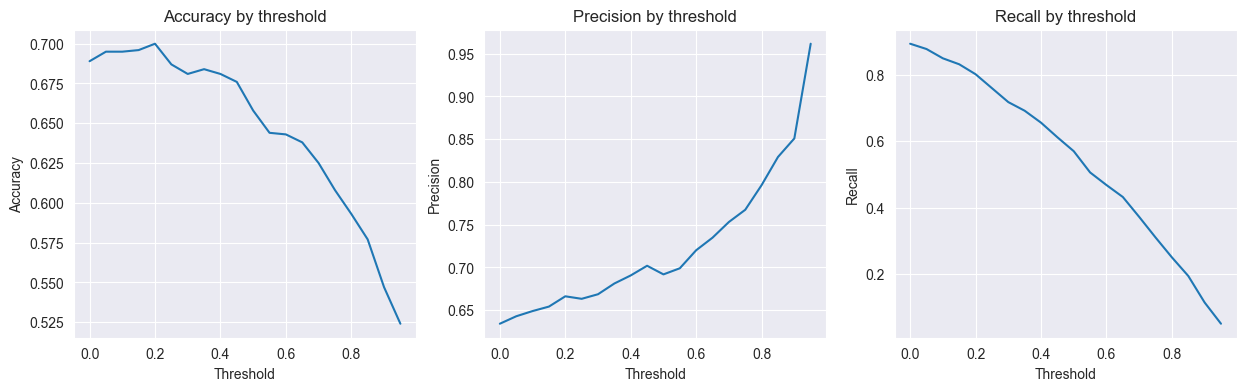

In [8]:
# Accuracy, precision and recall
sns.set_style('darkgrid')
metrics.plt_metrics_thr(real_test, pred_test)


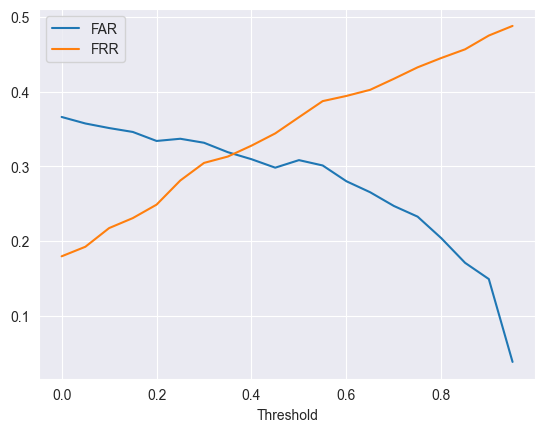

In [9]:
metrics.plot_far_frr(real_test, pred_test)

In [10]:
# False Acceptance Rate and False Rejection Rate
threshold, acc, precision, recall, FAR, FRR= metrics.all_metrics(real_test, pred_test)
pd.DataFrame({'threshold': threshold, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'FAR': FAR, 'FRR': FRR})

,threshold,Accuracy,Precision,Recall,FAR,FRR
0,0.0,0.689,0.634043,0.894,0.365957,0.179661
1,0.1,0.695,0.648855,0.850,0.351145,0.217391
2,0.2,0.700,0.666113,0.802,0.333887,0.248744
3,0.3,0.681,0.668529,0.718,0.331471,0.304536
4,0.4,0.681,0.690526,0.656,0.309474,0.327619
5,0.5,0.658,0.691748,0.570,0.308252,0.365646
6,0.6,0.643,0.720000,0.468,0.280000,0.394074
7,0.7,0.625,0.753036,0.372,0.246964,0.416999
8,0.8,0.593,0.796178,0.250,0.203822,0.444840
9,0.9,0.547,0.850746,0.114,0.149254,0.474812


Acuraccy: 0.700
Precision: 0.666
Recall: 0.802


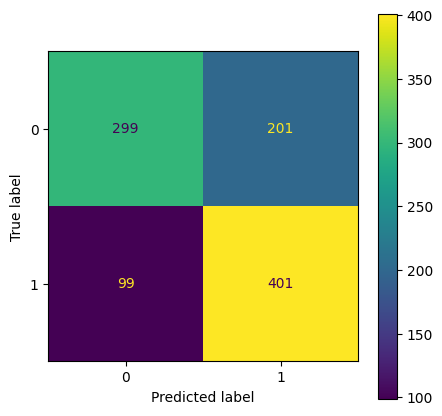

In [8]:
sns.reset_orig()

pred_thr_test = metrics.pred_threshold(pred_test, thr = 0.2)
metrics.plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.658
Precision: 0.692
Recall: 0.570


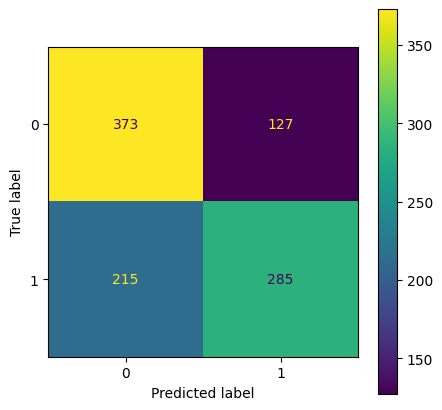

In [70]:
pred_thr_test = metrics.pred_threshold(pred_test, thr = 0.5)
metrics.plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.593
Precision: 0.796
Recall: 0.250


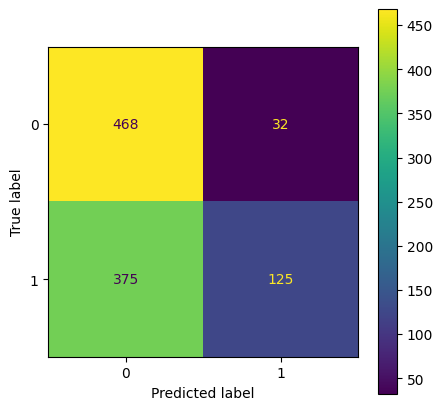

In [71]:
pred_thr_test = metrics.pred_threshold(pred_test, thr = 0.8)
metrics.plt_cm_metrics(real_test, pred_thr_test)

## Real user test

In [92]:
users_path = "./images/users_imgs/"
main_img = imread(users_path + "/sofia.jpg")
main_img = cv2.resize(main_img, (INPUT[0], INPUT[1])) / 255.

true_pairs_files = glob.glob(users_path + "/sofia*.jpg")
false_pairs_files = glob.glob(users_path + "/user_*.jpg")

true_pairs = np.zeros((len(true_pairs_files), INPUT[0], INPUT[1], INPUT[2]))
false_pairs = np.zeros((len(false_pairs_files), INPUT[0], INPUT[1], INPUT[2]))

for i, img_file in enumerate(true_pairs_files):
    img = imread(img_file)
    img = cv2.resize(img, (INPUT[0], INPUT[1]))
    true_pairs[i, :, :, :] = img / 255.

for i, img_file in enumerate(false_pairs_files):
    img = imread(img_file) 
    img = cv2.resize(img, (INPUT[0], INPUT[1]))
    false_pairs[i, :, :, :] = img / 255.

In [93]:
# Postive and negative pairs predictions
pred_main = model.predict(np.expand_dims(main_img, axis=0))
pred_true_pairs = model.predict(true_pairs)
pred_false_pairs = model.predict(false_pairs)

1/1 [==============================] - 0s 201ms/step


In [94]:
# Creating arrays of targets
real_test = np.concatenate((np.ones(len(true_pairs)), np.zeros(len(false_pairs))))

# Getting the similarity between true and false pairs
true_preds = [1 - distance.cosine(pred_main[0], pred_true_pairs[i]) for i in range(len(pred_true_pairs))]
false_preds = [1 - distance.cosine(pred_main[0], pred_false_pairs[i]) for i in range(len(pred_false_pairs))]

pred_test = np.concatenate((np.asarray(true_preds), np.asarray(false_preds)))

Acuraccy: 0.500
Precision: 0.500
Recall: 0.250


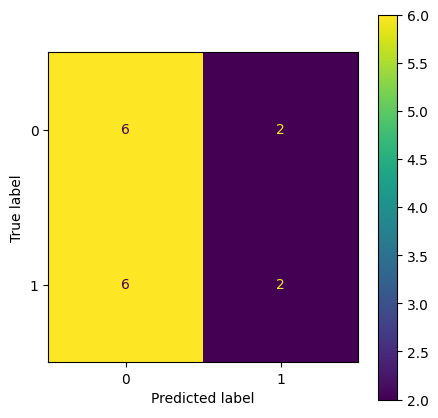

In [100]:
pred_thr_test = metrics.pred_threshold(pred_test, thr = 0.7)
metrics.plt_cm_metrics(real_test, pred_thr_test)